# Laboratorio 4 Regresión Logistica

## Lora Gallardo Rolando
## Descripcion del Dataset:
Conjunto de datos de setas simuladas para su clasificación binaria en comestibles y venenosas.

# Librerias usadas

In [122]:
# se utiliza para el manejo de rutas y directorios.
import os

# Calculo cientifico y vectorial para python
import numpy as np

# Librerias para graficar
from matplotlib import pyplot

# Modulo de optimización de scipy
from scipy import optimize

import pandas as pd

# le dice a matplotlib que incruste gráficos en el cuaderno
%matplotlib inline

# Cargar datos desde Google Drive

In [123]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [124]:
file_path = '/content/drive/MyDrive/Colab/datasets/secondary_data.csv'

data = pd.read_csv(file_path, sep=';')
print(f"✅ Dataset cargado. Forma: {df.shape}")  # (61069, 21)
print("\nPrimeras 5 filas:")
print(df.head())

✅ Dataset cargado. Forma: (61069, 21)

Primeras 5 filas:
  class  cap-diameter cap-shape cap-surface cap-color does-bruise-or-bleed  \
0     p         15.26         x           g         o                    f   
1     p         16.60         x           g         o                    f   
2     p         14.07         x           g         o                    f   
3     p         14.17         f           h         e                    f   
4     p         14.64         x           h         o                    f   

  gill-attachment gill-spacing gill-color  stem-height  ...  stem-root  \
0               e          NaN          w        16.95  ...          s   
1               e          NaN          w        17.99  ...          s   
2               e          NaN          w        17.80  ...          s   
3               e          NaN          w        15.77  ...          s   
4               e          NaN          w        16.53  ...          s   

  stem-surface stem-color vei

In [130]:
# Separar las características y la variable objetivo
X = data.drop('class', axis=1)
y = data['class']

print("X:")
print(X.head())

print("\ny:")
print(y.head())

X:
   cap-diameter cap-shape cap-surface cap-color does-bruise-or-bleed  \
0         15.26         x           g         o                    f   
1         16.60         x           g         o                    f   
2         14.07         x           g         o                    f   
3         14.17         f           h         e                    f   
4         14.64         x           h         o                    f   

  gill-attachment gill-spacing gill-color  stem-height  stem-width stem-root  \
0               e          NaN          w        16.95       17.09         s   
1               e          NaN          w        17.99       18.19         s   
2               e          NaN          w        17.80       17.74         s   
3               e          NaN          w        15.77       15.98         s   
4               e          NaN          w        16.53       17.20         s   

  stem-surface stem-color veil-type veil-color has-ring ring-type  \
0            y

#Preprocesamiento de datos

**4. Convertir la variable objetivo:** Se convierte la variable objetivo `y` (clase) de categórica a numérica (0 y 1) y se muestra su distribución.

In [131]:
y = y.map({'e': 0, 'p': 1})

print("\nDistribución de y:")
print(y.value_counts())


Distribución de y:
class
1    33888
0    27181
Name: count, dtype: int64


**5. Dividir 80% entrenamiento / 20% prueba:** El dataset se divide en conjuntos de entrenamiento y prueba para evaluar el rendimiento del modelo en datos no vistos.

In [132]:
m = len(X)
indices = np.random.permutation(m)
indice_corte = int(m * 0.8)
indices_train = indices[:indice_corte]
indices_test = indices[indice_corte:]

X_train = X.iloc[indices_train]
X_test = X.iloc[indices_test]
y_train = y.iloc[indices_train]
y_test = y.iloc[indices_test]

print("\nEntrenamiento:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nPrueba:")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)


Entrenamiento:
X_train: (48855, 20)
y_train: (48855,)

Prueba:
X_test: (12214, 20)
y_test: (12214,)


**6. Valores faltantes:** Se manejan los valores `NaN` en los conjuntos de características, reemplazándolos por 'missing' para la consistencia de los datos.

In [133]:
X_train = X_train.fillna('missing')
X_test = X_test.fillna('missing')

print("\nValores faltantes en X_train:", X_train.isna().sum().sum())
print("Valores faltantes en X_test:", X_test.isna().sum().sum())


Valores faltantes en X_train: 0
Valores faltantes en X_test: 0


**7. Convertir variables categóricas:** Las variables categóricas se transforman a un formato numérico mediante codificación one-hot (`pd.get_dummies`).

In [134]:
X_train = pd.get_dummies(X_train, drop_first=True, dtype=float)
X_test = pd.get_dummies(X_test, drop_first=True, dtype=float)

**8. Igualar las columnas de entrenamiento y prueba:** Se asegura que los conjuntos de entrenamiento y prueba tengan el mismo número de columnas después de la codificación one-hot.

In [135]:
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

print("\nDespués del preprocesamiento:")
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)


Después del preprocesamiento:
X_train: (48855, 111)
X_test: (12214, 111)


**9. Convertir a Numpy:** Los DataFrames se convierten a arreglos de NumPy para optimizar los cálculos matemáticos.

In [136]:
X_train = X_train.values.astype(float)
X_test = X_test.values.astype(float)
y_train = y_train.values.astype(float)
y_test = y_test.values.astype(float)

**10. Agregar columna de unos:** Se añade una columna de unos al principio de los conjuntos de características para el término de intercepción del modelo.

In [137]:
X_train = np.concatenate([np.ones((X_train.shape[0], 1)), X_train], axis=1)
X_test = np.concatenate([np.ones((X_test.shape[0], 1)), X_test], axis=1)

**11. Comprobar dimensiones finales:** Se verifican las dimensiones finales de los conjuntos de datos para asegurar que las transformaciones se aplicaron correctamente.

In [138]:
print("\nDimensiones finales:")
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)


Dimensiones finales:
X_train: (48855, 112)
X_test: (12214, 112)
y_train: (48855,)
y_test: (12214,)


**12. Theta inicial:** Se inicializa un vector `theta` con ceros, que representará los pesos del modelo.

In [139]:
initial_theta = np.zeros(X_train.shape[1])

print("initial_theta:", initial_theta.shape)

initial_theta: (112,)


In [140]:
# Función sigmoidea

def sigmoid(z):
    z = np.array(z)
    g = np.zeros(z.shape)
    g = 1 / (1 + np.exp(-z))
    return g


# Función de costo y gradiente

def costFunction(theta, X, y):
    # Inicializar algunos valores utiles
    m = y.size

    J = 0
    grad = np.zeros(theta.shape)

    h = sigmoid(X.dot(theta.T))

    # Evitar log(0) y log(1)
    h = np.clip(h, 1e-15, 1 - 1e-15)

    J = (1 / m) * np.sum(
        -y.dot(np.log(h)) -
        (1 - y).dot(np.log(1 - h))
    )

    grad = (1 / m) * (h - y).dot(X)

    return J, grad


# Theta inicial

initial_theta = np.zeros(X_train.shape[1])


# Costo inicial

cost, grad = costFunction(
    initial_theta,
    X_train,
    y_train
)

print('Costo inicial:', cost)


Costo inicial: 0.6931471805599428


In [141]:
def descensoGradiente(theta, X, y, alpha, num_iters):

    m = y.size

    J_history = []

    for i in range(num_iters):

        h = sigmoid(X.dot(theta.T))

        theta = theta - (alpha / m) * (h - y).dot(X)

        J, grad = costFunction(theta, X, y)

        J_history.append(J)

    return theta, J_history


# Parámetros de aprendizaje

alpha = 0.01
num_iters = 1000


# Entrenamiento

theta, J_history = descensoGradiente(
    initial_theta,
    X_train,
    y_train,
    alpha,
    num_iters
)


print('Costo inicial:', J_history[0])
print('Costo final:', J_history[-1])

Costo inicial: 0.6918575464490817
Costo final: 0.605925652711355


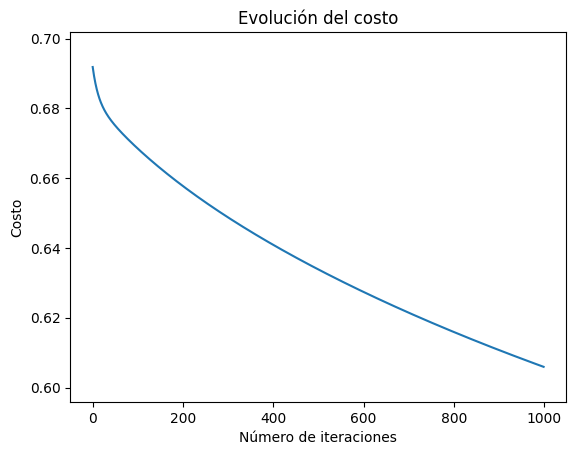

In [142]:
pyplot.plot(J_history)

pyplot.xlabel('Número de iteraciones')
pyplot.ylabel('Costo')
pyplot.title('Evolución del costo')

pyplot.ylim(min(J_history) - 0.01, max(J_history) + 0.01)

pyplot.show()

In [143]:
res = optimize.minimize(
    costFunction,
    initial_theta,
    (X_train, y_train),
    jac=True,
    method='TNC'
)

cost = res.fun
theta = res.x

print('Costo con optimize.minimize: {:.6f}'.format(cost))
print('Éxito:', res.success)
print('Mensaje:', res.message)
print('Número de iteraciones:', res.nit)

Costo con optimize.minimize: 0.315182
Éxito: True
Mensaje: Converged (|f_n-f_(n-1)| ~= 0)
Número de iteraciones: 51


In [144]:
def predict(theta, X):
    p = np.round(sigmoid(X.dot(theta.T)))
    return p


p_train = predict(theta, X_train)

print("Predicciones:", p_train[:10])

Predicciones: [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]


In [145]:
p_test = predict(theta, X_test)

print("Predicciones:", p_test[:10])

Predicciones: [0. 0. 0. 0. 1. 0. 0. 0. 1. 1.]


In [148]:
accuracy = np.mean(p_test == y_test) * 100

print('Precisión del modelo: {:.2f}%'.format(accuracy))

Precisión del modelo: 86.49%
